On va effectuer les calculs pour les graphes des présentation

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath('..'))  # on est dans notebooks/

In [4]:
# Ajoute la racine du projet et importe les modules/fonctions utiles
import sys, os
from pathlib import Path


# import pratique - atm_tools
from src.cosmo_lidar.atm_tools import (
    effective_area_and_waist,
    alpha_specific_function,
    optical_depth_emission,
    contribution_effective_area,
    Calcul_T_ant_1_el,
    Calcul_T_ant_2,
    calcul_PWV,
    calcul_z_percentile_wvc,
    vapor_pressure,
    mass_quantile_grid,
    pwv_profile,
    Calcul_T_sky_1_el
)

# import pratique - mc_tools
from src.cosmo_lidar.mc_tools import (
    generate_Pwater_MC,
    generate_Pwater_MC_lognormal,
    monte_carlo_t_ant,
    Monte_Carlo_T_ant_mod,
    local_bin_width,
    scale_snr_for_variable_bins,
    predict_SNR_T,
)

# import pratique - io
from src.cosmo_lidar.io import (
    fetch_html,
    extract_ut_column_dat_links,
    download_some,
    read_radiosonde_dat,
    read_many_radiosonde,
    save_table,
    load_table,
    load_parquet_columns_as_numpy,
    to_float64,
)

# Vérifie imports

print('Loaded atm_tools.Calcul_T_ant_1_el =', Calcul_T_ant_1_el)
print('Loaded mc_tools.predict_SNR_T =', predict_SNR_T)
print('Loaded io.read_many_radiosonde =', read_many_radiosonde)

Loaded atm_tools.Calcul_T_ant_1_el = <function Calcul_T_ant_1_el at 0x1661049a0>
Loaded mc_tools.predict_SNR_T = <function predict_SNR_T at 0x1661059e0>
Loaded io.read_many_radiosonde = <function read_many_radiosonde at 0x15f958220>


In [5]:
import matplotlib.pyplot as plt
import numpy as np
pi = np.pi
from scipy.interpolate import UnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid, cumulative_trapezoid



In [11]:
#Importation des données d'Octobre

T_acq = 60 #temps d'acquisition (s)
E_0 = 60.e-3 #emission ernergy (J)
F_t = 200 #shooting frequency (Hz)

#pour un angle d'élévation de 90°

e=90 # angle d'élévation (°)
# Charger les données (adapter le nom du fichier et éventuellement le délimiteur)
data_2 = np.loadtxt("/Users/vl284796/Downloads/Simulation_Atakama_lidarH2O_00-2.txt")

# Chaque colonne devient un tableau séparé
s_90_2    = data_2[:, 0]  # distance au lidar (km)
z_90_2     = data_2[:, 1]  # altitude (km)
r_H2O_90_2 = data_2[:, 2] *1000 # WVMR (g/kg)
s_rh_90_2  = data_2[:, 3]  # écart type (g/kg)
b_rh_90_2 = data_2[:, 4]  # biais (g/kg)
p_90 = data_2[:,5] #Pression en hPa
T_90 = data_2[:,6] #Temperature (K)

frequency = np.array([150.e9]) #en Hz
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600)) #en rad
elev = 90 #en
N_MC = 100

In [11]:
import matplotlib as mpl #pour choisir la taille des graphiques ?
mpl.rcParams['font.size'] = 16         # taille par défaut des labels/texte
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 13
mpl.rcParams['lines.linewidth'] = 2.5

Generating Pycraf Standard Profile...
Calculating Brightness Temperature Spectrum...


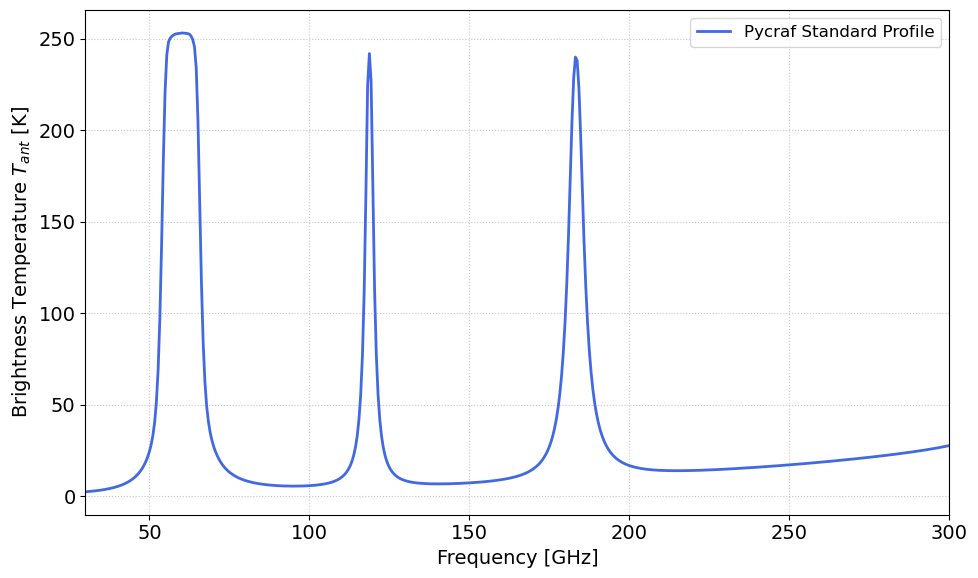

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf
from astropy import units as u
from scipy.integrate import trapezoid


# =============================================================================
# 3. SIMULATION SETUP
# =============================================================================

# Define Frequency range: 30 GHz to 300 GHz (Millimeter waves)
freq_array = np.linspace(30e9, 300e9, 500) # Hz
elevation_deg = 90 # Zenith

# Define Altitude Grid (Standard Atmosphere usually 0 to 80km)
# Using geomspace for better resolution at low altitudes
altitudes_m = np.geomspace(1, 25001, 1000) + 4999
altitudes_km_q = (altitudes_m * u.m).to(u.km)

# Get Pycraf Standard Profile
print("Generating Pycraf Standard Profile...")
profile = pycraf.atm.profile_standard(altitudes_km_q)
T_std = profile[0].value        # K
P_std = profile[1].value        # hPa
P_water = profile[3].value      # hPa

# =============================================================================
# 4. CALCULATION
# =============================================================================

print("Calculating Brightness Temperature Spectrum...")
T_ant_spectrum = Calcul_T_sky_1_el(
    freq_array, 
    altitudes_m, 
    T_std, 
    P_std, 
    P_water, 
    elevation_deg
)

# =============================================================================
# 5. PLOTTING
# =============================================================================

plt.figure(figsize=(10, 6))

# Plot the spectrum
plt.plot(freq_array / 1e9, T_ant_spectrum, color='royalblue', linewidth=2, label='Pycraf Standard Profile')

# Add Labels
plt.xlabel("Frequency [GHz]")
plt.ylabel("Brightness Temperature $T_{ant}$ [K]")
#plt.title(f"Atmospheric Brightness Temperature (Elevation = {elevation_deg}°)", fontsize=16)



# Grid and Layout
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.xlim(30, 300)
plt.legend()
plt.tight_layout()

plt.show()

Starting simulations...
 -> Calculating for Factor 1e-07x (PWV = 0.00 mm)...
 -> Calculating for Factor 1.0x (PWV = 1.23 mm)...
 -> Calculating for Factor 2.0x (PWV = 2.46 mm)...
 -> Calculating for Factor 3.0x (PWV = 3.69 mm)...


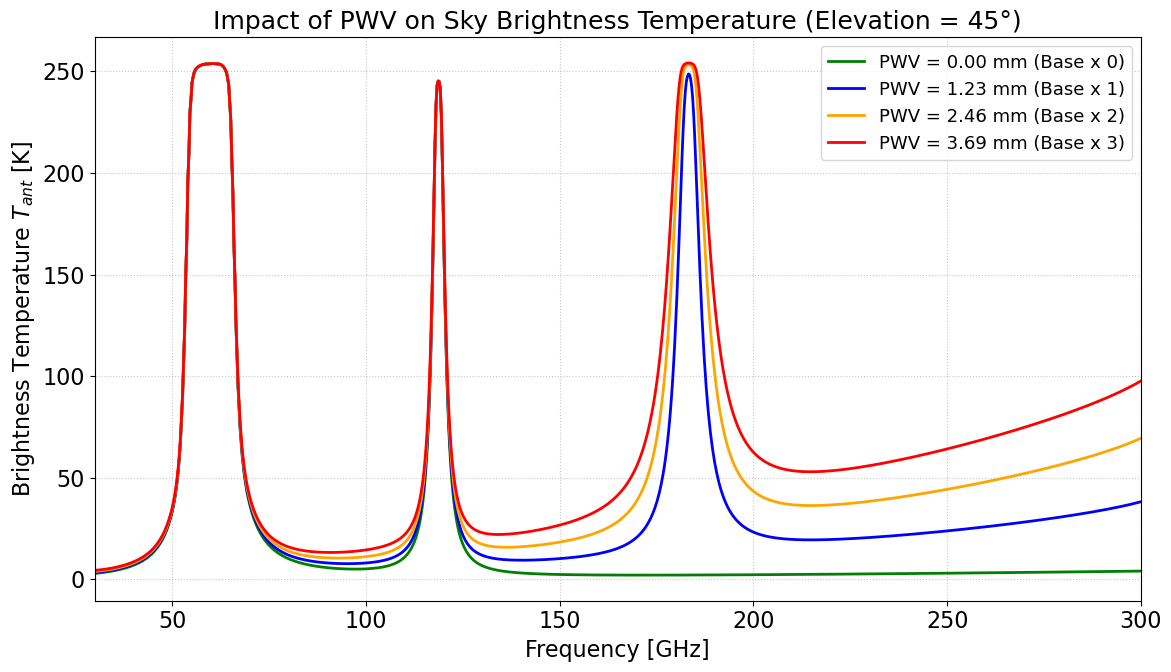

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf
from astropy import units as u
from scipy.integrate import trapezoid

# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================



def calc_pwv(p_water_hpa, temp_k, z_m):
    """
    Calculates the scalar PWV (mm) for a given profile.
    """
    R_water = 461.5 # J/(kg*K)
    # Ideal gas law: rho = P / (R*T)
    # P in Pa (*100), result in kg/m3 -> *1000 for g/m3
    rho_water = (p_water_hpa * 100) / (R_water * temp_k) * 1000
    
    # Integral -> g/m2 = 1/1000 kg/m2 (mm)
    pwv = trapezoid(rho_water, x=z_m) / 1000.0
    return pwv

# =============================================================================
# 2. SIMULATION SETUP
# =============================================================================

# Frequency range: 30 GHz to 300 GHz
freq_array = np.linspace(30e9, 300e9, 1000) # Hz
elevation_deg = 45 # 45° Elevation

# Altitude Grid (0 to 80km)
altitudes_m = np.geomspace(1, 25001, 1000)+4999 
altitudes_km_q = (altitudes_m * u.m).to(u.km)

# Get Pycraf Standard Base Profile
profile = pycraf.atm.profile_standard(altitudes_km_q)
T_std = profile[0].value        # K
P_std = profile[1].value        # hPa
P_water_base = profile[3].value # hPa (Base profile)

# Scaling factors requested
scaling_factors = [0.0000001, 1.0, 2.0, 3.0]
colors = ['green', 'blue', 'orange', 'red']

# =============================================================================
# 3. COMPUTATION LOOP
# =============================================================================

plt.figure(figsize=(12, 7))

print("Starting simulations...")


for factor, color in zip(scaling_factors, colors):
    
    # 1. Scale the Water Vapor Profile
    P_water_scaled = P_water_base * factor
    
    # 2. Calculate the actual PWV for this profile (for the legend)
    pwv_val = calc_pwv(P_water_scaled, T_std, altitudes_m)
    
    print(f" -> Calculating for Factor {factor}x (PWV = {pwv_val:.2f} mm)...")
    
    # 3. Compute Brightness Temperature Spectrum
    T_ant_spectrum = Calcul_T_sky_1_el(
        freq_array, 
        altitudes_m, 
        T_std, 
        P_std, 
        P_water_scaled, 
        elevation_deg
    )
    
    # 4. Plot
    label_txt = f"PWV = {pwv_val:.2f} mm (Base x {factor:.0f})"
    plt.plot(freq_array / 1e9, T_ant_spectrum, color=color, linewidth=2, label=label_txt)

# =============================================================================
# 4. PLOT FORMATTING
# =============================================================================

plt.xlabel("Frequency [GHz]")
plt.ylabel("Brightness Temperature $T_{ant}$ [K]" )
plt.title(f"Impact of PWV on Sky Brightness Temperature (Elevation = {elevation_deg}°)")



plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.xlim(30, 300)
plt.legend()
plt.tight_layout()

plt.show()

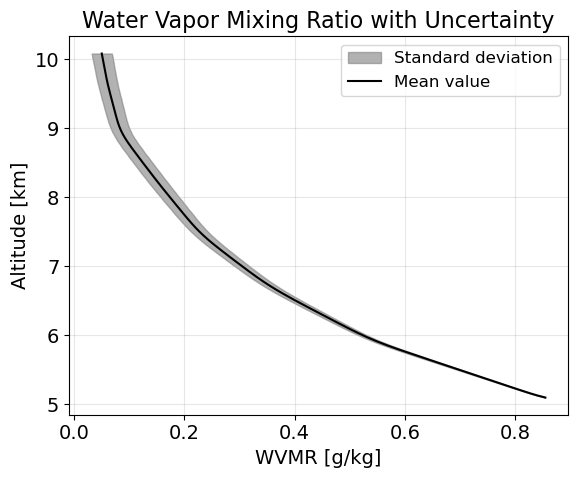

[6.21162618e-04 6.08587804e-04 5.97482254e-04 5.87044692e-04
 5.76907119e-04 5.66907829e-04 5.56991811e-04 5.47141517e-04
 5.37351540e-04 5.27620097e-04 5.17946572e-04 5.08330569e-04
 4.98771906e-04 4.89270290e-04 4.79825529e-04 4.70437419e-04
 4.61105730e-04 4.51830383e-04 4.42612011e-04 4.33453413e-04
 4.24362801e-04 4.15357980e-04 4.06469802e-04 3.97742501e-04
 3.89229053e-04 3.80982571e-04 3.73046157e-04 3.65444853e-04
 3.58275028e-04 3.51331235e-04 3.44675593e-04 3.38266412e-04
 3.32059732e-04 3.26014379e-04 3.20095059e-04 3.14273540e-04
 3.08528554e-04 3.02844916e-04 2.97212291e-04 2.91624013e-04
 2.86076277e-04 2.80567500e-04 2.75098127e-04 2.69670641e-04
 2.64289814e-04 2.58962795e-04 2.53699138e-04 2.48510436e-04
 2.43409572e-04 2.38409709e-04 2.33523075e-04 2.28735113e-04
 2.24074047e-04 2.19545715e-04 2.15167423e-04 2.10906056e-04
 2.06771036e-04 2.02752806e-04 1.98839425e-04 1.95017662e-04
 1.91274154e-04 1.87596319e-04 1.83973093e-04 1.80395356e-04
 1.76856067e-04 1.733502

In [13]:
#On retrace les courbes

plt.figure(figsize=(6,5))

# Profil moyen avec barres d’erreurs
# Fill between (mean - std, mean + std)
plt.fill_betweenx(z_90_2,
                  r_H2O_90_2 - s_rh_90_2,
                  r_H2O_90_2 + s_rh_90_2,
                  color="gray", alpha=0.6, label="Standard deviation")

# Mean line
plt.plot(r_H2O_90_2, z_90_2, 'k-', lw=1.5, label="Mean value")

# Labels and styling
plt.xlabel("WVMR [g/kg]")
plt.ylabel("Altitude [km]")
plt.title("Water Vapor Mixing Ratio with Uncertainty")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

R_d_air = 287 #J/(kg*K)
R_water = 462 #J/(kg*K)


rho_water = p_90*100*r_H2O_90_2/(1000*R_d_air*T_90)*1/(1+R_water/R_d_air*r_H2O_90_2/1000) #en kg/m3
rho_air = p_90*100/(R_water*T_90) - rho_water*R_water/R_d_air

P_water = rho_water*R_water*T_90/100 

print(rho_water)


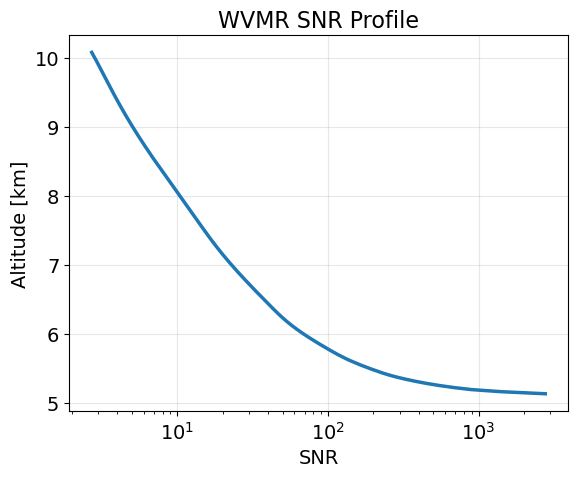

In [14]:
mu = r_H2O_90_2         # mean WVMR [g/kg]
s  = s_rh_90_2          # std [g/kg]
b  = b_rh_90_2          # bias [g/kg]

# avoid division by zero
eps = 1e-12
rmse = np.sqrt(s**2 + b**2)

SNR_rand    = mu / np.maximum(s, eps)
SNR_tot     = mu / np.maximum(rmse, eps)
SNR_rand_dB = 20*np.log10(SNR_rand)
SNR_tot_dB  = 20*np.log10(SNR_tot)

spline = UnivariateSpline(z_90_2[1:], SNR_rand[1:], s=1000)

snr_smooth_part = spline(z_90_2[1:])

# Réinsérer la première valeur brute
snr_smooth = np.insert(snr_smooth_part, 0, SNR_rand[0])


plt.figure(figsize=(6,5))
plt.plot(snr_smooth[1:], z_90_2[1:], lw=2.5)
plt.xlabel("SNR")
plt.xscale('log')
plt.ylabel("Altitude [km]")
plt.title("WVMR SNR Profile")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# -*- coding: utf-8 -*-
"""
Combo voie A + B pour SNR sur WVMR
----------------------------------
Modèle:
    Ns(z)  = A * exp(-2*(aR * IR(z) + aw * Iw(z))) / (z_rel**2)
    SNR(z) = Ns / sqrt(Ns + N0)

avec:
    z_rel = z_abs - z0_abs
    IR(z) = H * (1 - exp(-z_rel/H))              # proxy Rayleigh (densité ~ exp(-z/H))
    Iw(z) = ∫_0^{z_rel} q(u) du                  # colonne d'eau (WVMR)

Ajuste (A, N0, aR, aw, H) via scipy.optimize.least_squares (robuste).
"""

import numpy as np
from dataclasses import dataclass
from typing import Optional, Dict, Any
from scipy.optimize import least_squares


# ---------- utilitaires ----------
def cumtrapz_like(x: np.ndarray, f: np.ndarray) -> np.ndarray:
    """Intégrale cumulée trapézoïdale de f(x), même longueur (valeur 0 au premier point)."""
    x = np.asarray(x, float)
    f = np.asarray(f, float)
    out = np.zeros_like(f, dtype=float)
    if len(x) >= 2:
        dx = np.diff(x)
        out[1:] = np.cumsum(0.5 * (f[1:] + f[:-1]) * dx)
    return out


def sort_and_relative(z_abs: np.ndarray, q: np.ndarray, z0_abs: Optional[float]) -> Dict[str, np.ndarray]:
    """Trie par altitude croissante, calcule z_rel et retourne tout."""
    idx = np.argsort(z_abs)
    z_abs = np.asarray(z_abs, float)[idx]
    q = np.asarray(q, float)[idx]
    if z0_abs is None:
        z0_abs = float(z_abs[0])
    z_rel = z_abs - z0_abs
    return {"z_abs": z_abs, "z_rel": z_rel, "q": q, "z0_abs": float(z0_abs)}


def build_features(z_rel: np.ndarray, q: np.ndarray, H: float) -> Dict[str, np.ndarray]:
    """Construit IR et Iw pour un H donné (z_rel > 0 conseillé pour la SNR)."""
    z_rel = np.asarray(z_rel, float)
    q = np.asarray(q, float)
    # IR (proxy Rayleigh) et Iw (colonne d'eau)
    IR = H * (1.0 - np.exp(-np.clip(z_rel, 0, None) / H))
    Iw = cumtrapz_like(z_rel, q)
    return {"IR": IR, "Iw": Iw}


# ---------- modèle ----------
def snr_from_params(A: float, N0: float, aR: float, aw: float, z_rel: np.ndarray, IR: np.ndarray, Iw: np.ndarray) -> np.ndarray:
    """Calcule SNR linéaire à partir des paramètres et features."""
    # éviter z_rel=0 dans le dénominateur
    denom = np.where(z_rel > 0, z_rel, np.nan)
    Ns = A * np.exp(-2.0 * (aR * IR + aw * Iw)) / (denom ** 2)
    return Ns / np.sqrt(Ns + N0)


# ---------- ajustement ----------
@dataclass
class FitOptions:
    z0_abs: Optional[float] = None       # altitude de référence (m ou km, cohérent avec z_abs)
    zmin_abs: Optional[float] = None     # fenêtre de fit (optionnel)
    zmax_abs: Optional[float] = None
    fit_H: bool = True                   # ajuste H (sinon H fixé à H0)
    H0: Optional[float] = None           # valeur initiale/fixée de H (m si z en m; km si z en km)
    loss: str = "soft_l1"                # perte robuste: 'linear' | 'soft_l1' | 'huber' | 'cauchy' | 'arctan'
    f_scale: float = 0.5                 # échelle de robustesse (plus petit = plus robuste)
    max_nfev: int = 2000                 # itérations max de least_squares


def _initial_guess(z_rel: np.ndarray, q: np.ndarray) -> Dict[str, float]:
    """Devine des valeurs initiales raisonnables (ordre de grandeur)."""
    # simple heuristique
    H0 = np.nanmax(z_rel) / 3.0 if np.nanmax(z_rel) > 0 else 1.0
    # fit log-linéaire shot-noise pour init A, aR+aw combinés (approx)
    # ln[SNR * z_rel] ≈ const - b0*z_rel - bw*∫q dz
    mask = np.isfinite(z_rel) & (z_rel > 0)
    z_rel_m = z_rel[mask]
    # features basiques
    Iw = cumtrapz_like(z_rel_m, q[mask])
    # on met IR_lin = z_rel (approx de petite profondeur)
    X = np.column_stack([np.ones_like(z_rel_m), -z_rel_m, -Iw])
    # provisoire: SNR inconnu -> on suppose une pseudo SNR ~ 1/(z_rel) pour init (ne pèse pas beaucoup)
    y = np.log(1.0) * np.ones_like(z_rel_m)
    try:
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        lnK, bR, bW = beta
        K = np.exp(lnK)
    except Exception:
        K = 1.0
    A0 = max(K**2, 1e-8)
    return {"A0": A0, "N00": 1e-3, "aR0": 1e-4, "aw0": 1e-5, "H0": H0}


def fit_snr_combo(z_abs: np.ndarray,
                  q: np.ndarray,
                  snr: np.ndarray,
                  opts: FitOptions = FitOptions()) -> Dict[str, Any]:
    """
    Ajuste (A, N0, aR, aw, [H]) dans le modèle combo (voie A + B).
    - z_abs, q, snr : 1D, même longueur. Unités cohérentes (tout en m OU tout en km).
    - opts : voir FitOptions.
    Retourne un dict avec paramètres ajustés et méta.
    """
    snr = np.asarray(snr, float)
    grids = sort_and_relative(z_abs, q, opts.z0_abs)
    z_abs = grids["z_abs"]; z_rel = grids["z_rel"]; q = grids["q"]; z0_abs = grids["z0_abs"]

    # masque valide & fenêtre
    mask = np.isfinite(snr) & (snr > 0) & np.isfinite(z_rel) & (z_rel > 0)
    if opts.zmin_abs is not None:
        mask &= (z_abs >= opts.zmin_abs)
    if opts.zmax_abs is not None:
        mask &= (z_abs <= opts.zmax_abs)
    if not np.any(mask):
        raise ValueError("Masque vide : vérifiez z0_abs, la fenêtre ou les données.")

    z_rel_m = z_rel[mask]; q_m = q[mask]; y = snr[mask]

    # init
    ini = _initial_guess(z_rel_m, q_m)
    H0 = opts.H0 if (opts.H0 is not None) else ini["H0"]
    A0, N00, aR0, aw0 = ini["A0"], ini["N00"], ini["aR0"], ini["aw0"]

    # paramètres en log pour positivité
    if opts.fit_H:
        theta0 = np.array([np.log(A0), np.log(N00), np.log(aR0), np.log(aw0), np.log(H0)])
    else:
        theta0 = np.array([np.log(A0), np.log(N00), np.log(aR0), np.log(aw0)])

    def residuals(theta):
        # unpack
        if opts.fit_H:
            lnA, lnN0, lnaR, lnaw, lnH = theta
            H = np.exp(lnH)
        else:
            lnA, lnN0, lnaR, lnaw = theta
            H = H0
        A, N0, aR, aw = np.exp([lnA, lnN0, lnaR, lnaw])

        feats = build_features(z_rel_m, q_m, H)
        yhat = snr_from_params(A, N0, aR, aw, z_rel_m, feats["IR"], feats["Iw"])
        # résidus en linéaire (option robuste via least_squares)
        return yhat - y

    res = least_squares(
        residuals,
        x0=theta0,
        loss=opts.loss,
        f_scale=opts.f_scale,
        max_nfev=opts.max_nfev
    )

    theta_hat = res.x
    if opts.fit_H:
        lnA, lnN0, lnaR, lnaw, lnH = theta_hat
        pars = {
            "A": float(np.exp(lnA)),
            "N0": float(np.exp(lnN0)),
            "aR": float(np.exp(lnaR)),
            "aw": float(np.exp(lnaw)),
            "H": float(np.exp(lnH)),
        }
    else:
        lnA, lnN0, lnaR, lnaw = theta_hat
        pars = {
            "A": float(np.exp(lnA)),
            "N0": float(np.exp(lnN0)),
            "aR": float(np.exp(lnaR)),
            "aw": float(np.exp(lnaw)),
            "H": float(H0),
        }

    # métriques
    feats = build_features(z_rel_m, q_m, pars["H"])
    yhat = snr_from_params(pars["A"], pars["N0"], pars["aR"], pars["aw"], z_rel_m, feats["IR"], feats["Iw"])
    rms = float(np.sqrt(np.mean((yhat - y) ** 2)))

    return {
        **pars,
        "success": bool(res.success),
        "message": res.message,
        "cost": float(res.cost),
        "rms": rms,
        "nfev": int(res.nfev),
        "mask_used": mask,
        "z0_abs": float(z0_abs)
    }


def predict_snr_combo(z_abs: np.ndarray,
                      q: np.ndarray,
                      A: float, N0: float, aR: float, aw: float, H: float,
                      z0_abs: Optional[float] = None) -> Dict[str, np.ndarray]:
    """Prédit SNR et retourne aussi IR/Iw/z_rel pour traçage."""
    grids = sort_and_relative(z_abs, q, z0_abs)
    z_abs = grids["z_abs"]; z_rel = grids["z_rel"]; q = grids["q"]; z0_abs = grids["z0_abs"]
    feats = build_features(z_rel, q, H)
    yhat = snr_from_params(A, N0, aR, aw, z_rel, feats["IR"], feats["Iw"])
    return {"snr": yhat, "z_abs": z_abs, "z_rel": z_rel, "IR": feats["IR"], "Iw": feats["Iw"], "z0_abs": z0_abs}


from math import isnan
z_abs = z_90_2[1:] * 1000        # m (on évite le tout premier point)
q     = r_H2O_90_2[1:]           # WVMR aligné
snr_meas   = snr_smooth[1:]           # SNR aligné
z0_abs    = z_90_2[0] * 1000 
z_rel = z_abs -z0_abs 
H = 8000.0


opts = FitOptions(z0_abs=z0_abs, fit_H=True, H0=H, loss="soft_l1", f_scale=0.7)
fit = fit_snr_combo(z_abs, q, snr_meas, opts)
pred = predict_snr_combo(z_abs, q, fit["A"], fit["N0"], fit["aR"], fit["aw"], fit["H"], z0_abs=fit["z0_abs"])
print(fit)

snr_inch = pred["snr"]

    # # Plot
    # plt.figure()
    # plt.semilogx(snr_meas, z_abs/1000, '.', label="mesuré (synthetic)")
    # plt.semilogx(pred["snr"], z_abs/1000, '-', label="modèle A+B (fit)")
    # plt.grid(True); plt.xlabel("SNR (linéaire)"); plt.ylabel("Altitude [km]"); plt.legend()
    # plt.title("SNR WVMR — combo voie A + B")
    # plt.show()



import numpy as np
from typing import Optional, Dict

def _cumtrapz_like(x: np.ndarray, f: np.ndarray) -> np.ndarray:
    """
    Intégrale cumulée trapézoïdale de f(x) avec la même longueur que x.
    Renvoie 0 au premier point.
    """
    x = np.asarray(x, float)
    f = np.asarray(f, float)
    out = np.zeros_like(f, dtype=float)
    if len(x) >= 2:
        dx = np.diff(x)
        out[1:] = np.cumsum(0.5 * (f[1:] + f[:-1]) * dx)
    return out


def compute_IR_IW(
    z: np.ndarray, 
    q: np.ndarray, 
    H: float, 
    z0: Optional[float] = None,
    assume_sorted: bool = False
) -> Dict[str, np.ndarray]:
    """
    Calcule IR et Iw pour la voie B (proxy Rayleigh + colonne d’eau).

    Paramètres
    ----------
    z : array (N,)
        Altitudes (m OU km, mais uniforme partout).
    q : array (N,)
        WVMR aux mêmes altitudes (unité quelconque, mais constante).
    H : float
        Hauteur d’échelle pour le proxy Rayleigh (m si z en m ; km si z en km).
    z0 : float, optionnel
        Altitude de référence (début utile). Si None -> min(z trié).
    assume_sorted : bool
        Si False (défaut), on trie z et q par ordre croissant d’altitude.

    Définitions
    -----------
    z_rel = z - z0
    IR(z) = H * (1 - exp(-z_rel/H))                     # proxy Rayleigh
    Iw(z) = ∫_0^{z_rel} q(u) du                         # colonne d’eau via trapèzes

    Retour
    ------
    dict avec clés:
      - "IR": array (N,)
      - "Iw": array (N,)
      - "z_sorted": array (N,)
      - "z_rel": array (N,)
      - "q_sorted": array (N,)
      - "z0": float
    """
    z = np.asarray(z, float)
    q = np.asarray(q, float)
    if not assume_sorted:
        idx = np.argsort(z)
        z = z[idx]
        q = q[idx]

    if z0 is None:
        z0 = float(z[0])
    z_rel = z - z0

    # IR : proxy Rayleigh basé sur densité ~ exp(-z/H)
    z_rel_pos = np.clip(z_rel, 0, None)  # éviter valeurs négatives avant z0
    IR = H * (1.0 - np.exp(-z_rel_pos / H))

    # Iw : colonne d’eau par intégration cumulée
    Iw = _cumtrapz_like(z_rel, q)

    return {"IR": IR, "Iw": Iw, "z_sorted": z, "z_rel": z_rel, "q_sorted": q, "z0": z0}

{'A': 7350529829.075809, 'N0': 1.0244874615346347e-06, 'aR': 0.0003564186913625303, 'aw': 9.110808513015025e-09, 'H': 79485751.78855298, 'success': True, 'message': '`xtol` termination condition is satisfied.', 'cost': 80.1903135590188, 'rms': 4.750731107980566, 'nfev': 43, 'mask_used': array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True

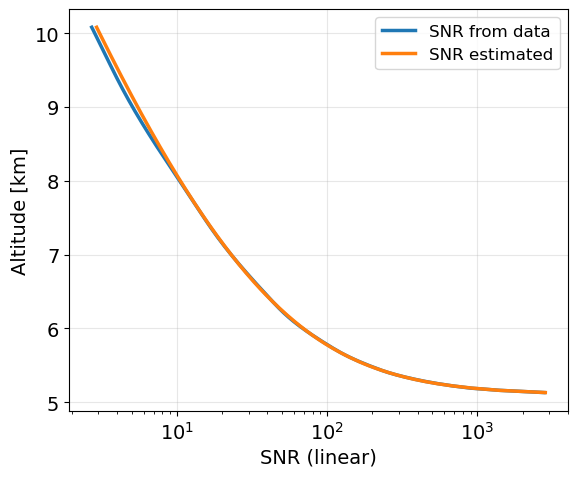

In [16]:
#pred_2 = predict_snr_combo(z_abs, q, fit["A"], fit["N0"], fit["aR"], fit["aw"], fit["H"]/, z0_abs=fit["z0_abs"])


#snr_inch_2 = pred_2["snr"]

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(snr_smooth[1:], z_90_2[1:], label='SNR from data')
#ax.plot(SNR_test, z_90_2)
ax.plot(snr_inch, z_90_2[1:], label= 'SNR estimated')
#ax.plot(snr_inch_2, z_90_2[1:], label= 'SNR recalculé bis')
ax.set_xlabel("SNR (linear)")
ax.set_xscale("log")

ax.set_ylabel("Altitude [km]")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

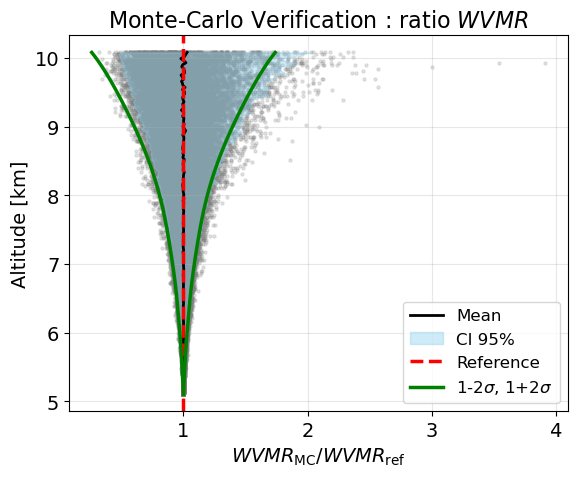

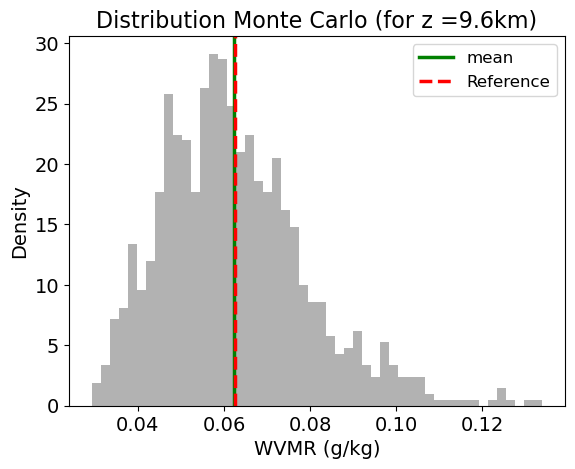

In [17]:
N_MC = 1000
rel_sigma_WVMR_90 = 1/snr_smooth

r_H2O_90_MC = generate_Pwater_MC_lognormal(r_H2O_90_2, N_MC, rel_sigma_WVMR_90, rng=None)

WVMR0 = np.asarray(r_H2O_90_2, dtype=float)
WVMRmc = np.asarray(r_H2O_90_MC, dtype=float)

# Rapport (N_MC, n_alt)

ratio = np.where(WVMR0 == 0, WVMRmc/WVMR0, WVMRmc / WVMR0)
# Altitude en km pour affichage
z_km = z_90_2

# Moyenne et quantiles du rapport
ratio_mean = np.nanmean(ratio, axis=0)
ratio_p05  = np.nanpercentile(ratio, 5, axis=0)
ratio_p95  = np.nanpercentile(ratio, 95, axis=0)
ratio_p2_45  = np.nanpercentile(ratio, 2.45, axis=0)
ratio_p97_725  = np.nanpercentile(ratio, 97.725, axis=0)




plt.figure(figsize=(6,5))

# --- Nuage de points (sous-échantillonnage aléatoire) ---
N_MC, n_alt = ratio.shape
rng = np.random.default_rng(42)  # seed pour reproductibilité
n_draws_plot = min(300, N_MC)    # max 200 profils affichés
idx = rng.choice(N_MC, size=n_draws_plot, replace=False)

for i in idx:
    plt.scatter(ratio[i, :], z_km, s=5, color="grey", alpha=0.2)

# --- Moyenne et quantiles ---
plt.plot(ratio_mean, z_km, 'k-', lw=2, label='Mean')
plt.fill_betweenx(z_km, ratio_p2_45, ratio_p97_725, color='skyblue', alpha=0.4, label='CI 95%')
plt.axvline(1.0, color='red', linestyle='--', label='Reference')
plt.plot(1+2/snr_smooth, z_km, color ='green', label = r'1-2$\sigma$, 1+2$\sigma$')
plt.plot(1-2/snr_smooth, z_km, color = 'green')

# --- Mise en forme ---
plt.xlabel(r"$WVMR_{\mathrm{MC}} / WVMR_{\mathrm{ref}}$")
plt.ylabel("Altitude [km]")
plt.title("Monte-Carlo Verification : ratio $WVMR$")
plt.legend()
#plt.xscale("log")
#plt.xlim(left = 1e-3)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



i_alt = 150  # par exemple, altitude index 10
plt.hist(r_H2O_90_MC[:, i_alt], bins=50, density=True, alpha=0.6, color="gray")
plt.axvline(np.mean(r_H2O_90_MC[:, i_alt]), color="g", linestyle="-", label="mean")
plt.axvline(r_H2O_90_2[i_alt], color="r", linestyle="--", label="Reference")
plt.xlabel("WVMR (g/kg)")
plt.ylabel("Density")
plt.title(f"Distribution Monte Carlo (for z ={z_90_2[i_alt]}km)")
plt.legend()
plt.show()

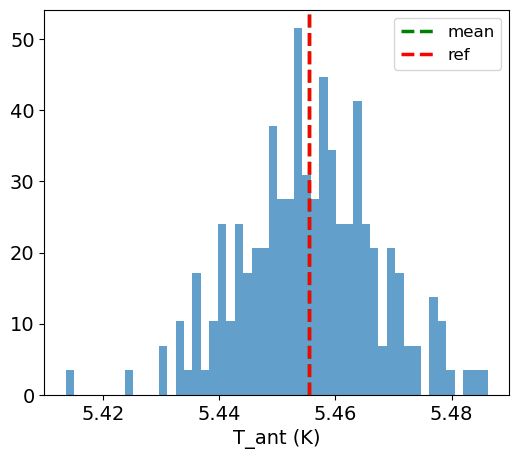

(np.float64(0.011812450025271218), array([5.45539588]))


In [18]:
N=500
N_MC=200
simu = monte_carlo_t_ant(frequency,theta_b, N , elev, generate_Pwater_MC_lognormal, N_MC , r_H2O_90_2, s_rh_90_2, T_90, p_90, z_90_2*1000)
print(simu)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
# Lire le fichier .txt


cols = ["TIME", "PMB", "TEMP", "TDEW", "RH", 
        "GEOP", "AZ", "EL", "SPEED", "DIR", 
        "E.TIME", "RT", "Battery"]

df_1 = pd.read_csv('/Users/vl284796/Downloads/data 25 avril.txt', 
                 delim_whitespace=True, 
                 skiprows=1, 
                 names=cols, encoding='latin-1')

time = df_1["TIME"].values
temp = pd.to_numeric(df_1["TEMP"], errors="coerce").values[2:-1780] + 273.15 #en K
alt = pd.to_numeric(df_1["GEOP"], errors="coerce").values[2:-1780] *1.e-3 #en km
rh   = pd.to_numeric(df_1["RH"], errors="coerce").values[2:-1780] #%
T_DEW = pd.to_numeric(df_1["TDEW"], errors="coerce").values[2:-1780] +273.15 # en K
P_data =  pd.to_numeric(df_1["PMB"], errors="coerce").values[2:-1780] #en hPa



e_1= vapor_pressure(T_DEW) #hPa
r_WVMR_1 = 0.622*e_1/(P_data-e_1) #kg/kg

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_47241/2512275130.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_1 = pd.read_csv('/Users/vl284796/Downloads/data 25 avril.txt',


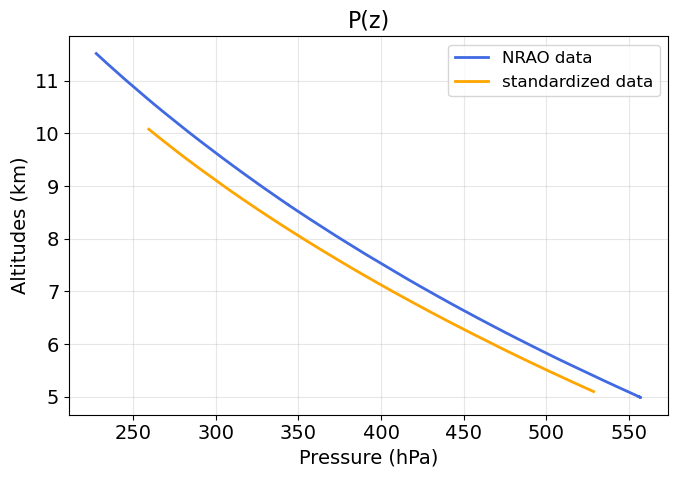

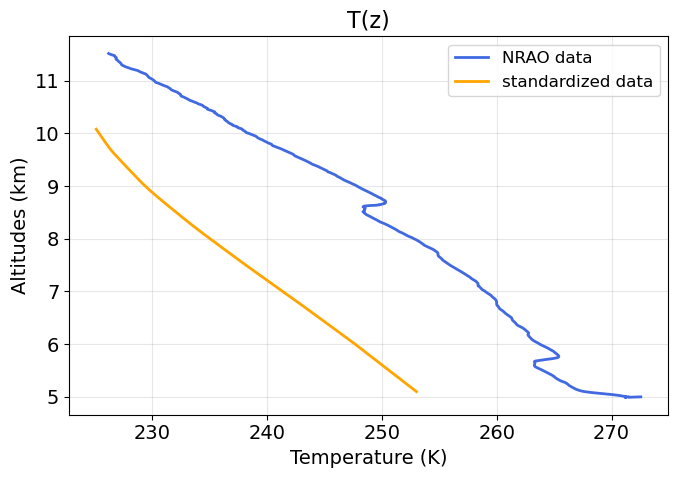

In [20]:

plt.figure(figsize=(7,5))
plt.plot(P_data, alt, label="NRAO data", color='royalblue', linewidth=2)
plt.plot(p_90, z_90_2, label="standardized data", color='orange', linewidth=2)


# Mise en forme
plt.xlabel("Pressure (hPa)")
plt.ylabel("Altitudes (km)")
plt.title("P(z)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
plt.plot(temp, alt, label="NRAO data", color='royalblue', linewidth=2)
plt.plot(T_90, z_90_2, label="standardized data", color='orange', linewidth=2)


# Mise en forme
plt.xlabel("Temperature (K)")
plt.ylabel("Altitudes (km)")
plt.title("T(z)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

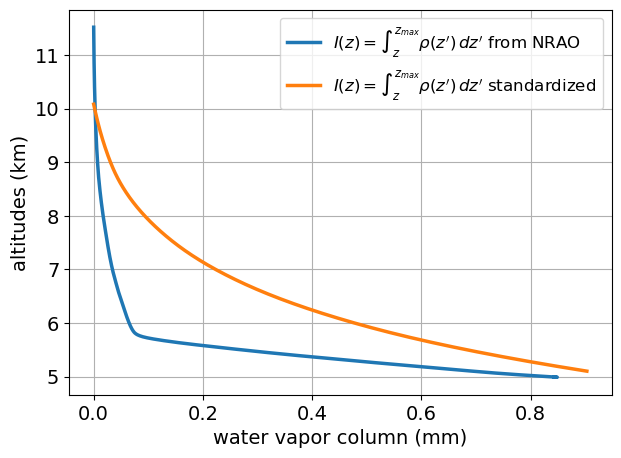

In [21]:
WVMR = r_WVMR_1 #g/kg
rho_water_1 = P_data*100*WVMR/(R_d_air*temp)*1/(1+R_water/R_d_air*WVMR) #en kg/m3

integrale_cum = cumulative_trapezoid(rho_water_1[1:], alt[1:]*1000, initial=0)

# Valeur totale de l’intégrale
I_tot = integrale_cum[-1]

# Pour chaque z_i : intégrale de z_i à z_max
I_from_z = I_tot - integrale_cum

integrale_cum = cumulative_trapezoid(rho_water, z_90_2*1000, initial=0)

# Valeur totale de l’intégrale
I_tot = integrale_cum[-1]

# Pour chaque z_i : intégrale de z_i à z_max
I_from_z_90 = I_tot - integrale_cum

# Tracé
plt.figure(figsize=(7,5))
plt.plot(I_from_z, alt[1:], label=r"$I(z)=\int_z^{z_{max}} \rho(z')\,dz'$ from NRAO")
plt.plot(I_from_z_90, z_90_2, label=r"$I(z)=\int_z^{z_{max}} \rho(z')\,dz'$ standardized")
#plt.plot(I_from_z_45, z_45_2, label=r"$I(z)=\int_z^{z_{max}} \rho(z')\,dz'$ 45")

plt.xlabel("water vapor column (mm)")
plt.ylabel("altitudes (km)")
#plt.ylim(top = 10)
plt.legend()
plt.grid(True)
plt.show()


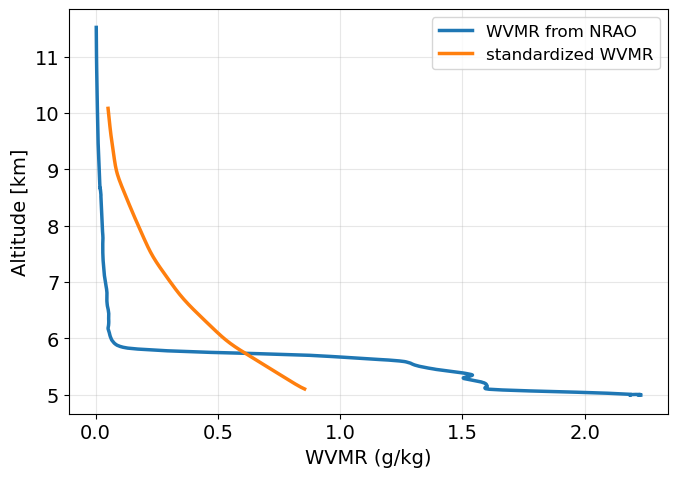

In [22]:
z = alt[1:]
WVMR = r_WVMR_1[1:]*1000


fig, ax = plt.subplots(figsize=(7,5))
ax.plot(WVMR, z, label='WVMR from NRAO')
ax.plot(r_H2O_90_2, z_90_2, label='standardized WVMR')
#ax.plot(SNR_test, z_90_2)
#ax.plot(pred_2, z_45_2, label= 'SNR recalculé')
ax.set_xlabel("WVMR (g/kg)")
#ax.set_xscale("log")

ax.set_ylabel("Altitude [km]")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

[2.22966299e-03 2.22347270e-03 2.22032752e-03 ... 2.40016851e-06
 2.39711278e-06 2.39038251e-06]


/Users/vl284796/Documents/Cosmo-Lidar-Project/Cosmo-lidar-project/src/cosmo_lidar/mc_tools.py:529: RuntimeWarning: invalid value encountered in sqrt
  factor = np.sqrt(dz_local*np.sin(elev*pi/180) / dz_ref)


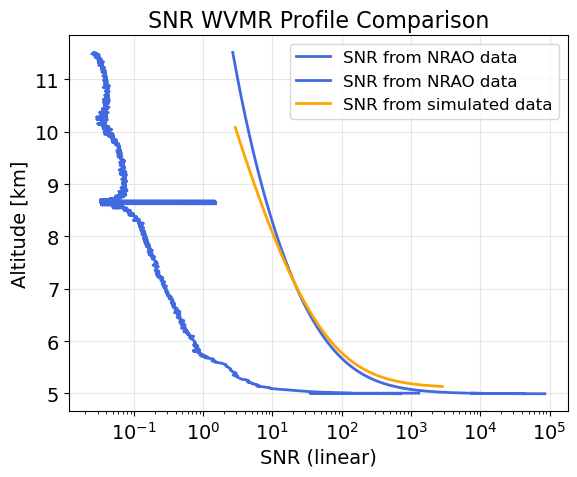

In [ ]:
A= 7350529829.075809
N0 = 1.0244874615346347e-06 
aR = 0.0003564186913625303
aw = 9.110808513015025e-09
elev = 90

WVMR = r_WVMR_1[1:]

print(WVMR)
snr_nrao = calcul_snr (A, N0, aR, aw, WVMR, z*1000, elev)

snr_nrao_2 = scale_snr_for_variable_bins(z, snr_nrao, elev, dz_ref=30.0) [0]

plt.figure(figsize=(6,5))
plt.plot(snr_nrao, z, label='SNR from NRAO data', color='royalblue', linewidth=2)
plt.plot(snr_nrao_2, z, label='SNR from NRAO data', color='royalblue', linewidth=2)
plt.plot(snr_inch, z_90_2[1:], label='SNR from simulated data', color='orange', linewidth=2)
plt.xlabel("SNR (linear)")
plt.xscale("log")
plt.ylabel("Altitude [km]")
plt.title("SNR WVMR Profile Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [24]:
N_MC = 200
print(WVMR.shape,T_90[1:].shape,P_data[1:].shape,z.shape)
simu = predict_SNR_T (frequency, theta_b,z,WVMR,elev,temp[1:],P_data[1:],N_MC)
print(simu)

(1872,) (166,) (1872,) (1872,)
(np.float64(nan), array([0.00057043]))


Loading ../data/nrao_all_filter/interpolated_profiles.npz...
Calculating Pycraf Standard Profile...
Selected profiles: ['01042718_geop5000.parquet', '98101103_geop5000.parquet', '98120623_geop5000.parquet', '01042518_geop5000.parquet', '00072302_geop5000.parquet']


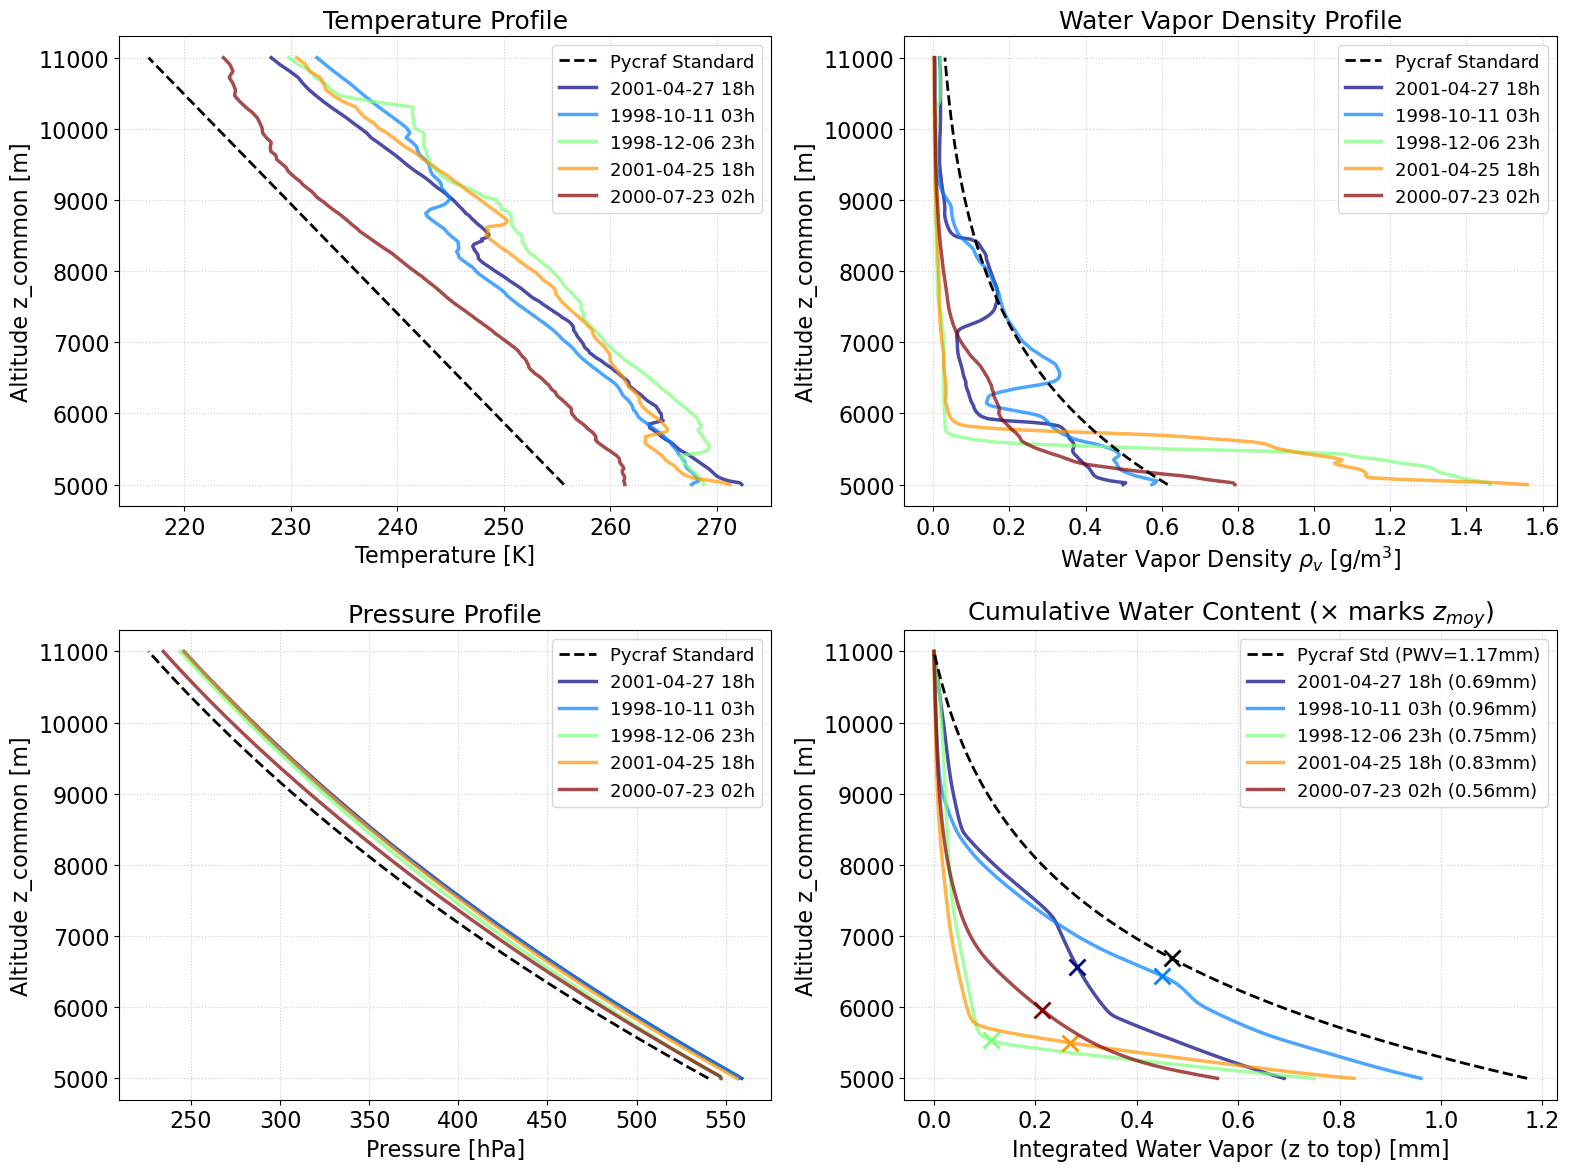

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import cumulative_trapezoid, trapezoid
import random
import pycraf
from astropy import units as u

# =============================================================================
# 1. SETUP AND LOADING
# =============================================================================

# Paths
OUTPUT_DIR = Path("../data/nrao_all_filter")
file_path = OUTPUT_DIR / "interpolated_profiles.npz"

# Constants
R_WATER = 461.5  # J/(kg.K)

# Loading data
print(f"Loading {file_path}...")
loaded = np.load(file_path, allow_pickle=True)
z_common = loaded['z_grid']          # Altitude grid (m)
data_dict = loaded['data'].item()    # Dictionary of profiles

# Helper function to parse date from filename
def parse_date_from_filename(filename):
    prefix = filename.split('_')[0]
    yy = int(prefix[0:2])
    mm = int(prefix[2:4])
    dd = int(prefix[4:6])
    hh = int(prefix[6:8])
    
    if yy > 90: year = 1900 + yy
    else:       year = 2000 + yy
        
    return f"{year}-{mm:02d}-{dd:02d} {hh:02d}h"

# =============================================================================
# 2. PYCRAF REFERENCE CALCULATION
# =============================================================================

# Convert grid to km for Pycraf
z_common_km = (z_common * u.m).to(u.km)

# Get Standard Profile
print("Calculating Pycraf Standard Profile...")
profile_std = pycraf.atm.profile_standard(z_common_km)
T_std = profile_std[0].value        # K
P_std = profile_std[1].value        # hPa
Pw_std = profile_std[3].value       # hPa

# Physics for Pycraf
# 1. Density
rho_std = (Pw_std * 100.0) / (R_WATER * T_std) * 1000.0 # g/m^3

# 2. Total PWV
pwv_total_std = trapezoid(rho_std, x=z_common) / 1000.0

# 3. Center of Mass (z_moy)
if pwv_total_std > 0:
    zmoy_std = trapezoid(rho_std * z_common, x=z_common) / (pwv_total_std * 1000.0)
else:
    zmoy_std = 0

# 4. Integrated Profile
cumul_std = cumulative_trapezoid(rho_std, x=z_common, initial=0) / 1000.0
int_water_std = pwv_total_std - cumul_std
int_water_std[-1] = 0.0

# =============================================================================
# 3. SELECTION OF PROFILES
# =============================================================================

all_files = list(data_dict.keys())
random.seed(45) 
selected_files = random.sample(all_files, 5)
print(f"Selected profiles: {selected_files}")

# =============================================================================
# 4. COMPUTATION AND PLOTTING
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax_temp = axes[0, 0]  # Top Left
ax_pres = axes[1, 0]  # Bottom Left
ax_rho  = axes[0, 1]  # Top Right
ax_int  = axes[1, 1]  # Bottom Right

# --- PLOT PYCRAF REFERENCE FIRST (Black Dashed) ---
style_std = {'color': 'black', 'linestyle': '--', 'linewidth': 2, 'zorder': 10}

ax_temp.plot(T_std, z_common, label='Pycraf Standard', **style_std)
ax_pres.plot(P_std, z_common, label='Pycraf Standard', **style_std)
ax_rho.plot(rho_std, z_common, label='Pycraf Standard', **style_std)

# For integrated, we include PWV in label and plot the cross
y_at_zmoy_std = np.interp(zmoy_std, z_common, int_water_std)
ax_int.plot(int_water_std, z_common, label=f'Pycraf Std (PWV={pwv_total_std:.2f}mm)', **style_std)
ax_int.plot(y_at_zmoy_std, zmoy_std, marker='x', color='black', markersize=12, markeredgewidth=2, zorder=11)


# --- PLOT SELECTED REAL PROFILES ---
colors = plt.cm.jet(np.linspace(0, 1, len(selected_files)))

for i, filename in enumerate(selected_files):
    
    # 1. Data Extraction
    prof_data = data_dict[filename]
    T = prof_data['Temperature'] 
    P = prof_data['Pressure']    
    P_w = prof_data['P_water']   
    
    date_label = parse_date_from_filename(filename)
    
    # 2. Physics Calculations
    rho_water = (P_w * 100.0) / (R_WATER * T) * 1000.0 
    pwv_total = trapezoid(rho_water, x=z_common) / 1000.0
    
    if pwv_total > 0:
        z_moy = trapezoid(rho_water * z_common, x=z_common) / (pwv_total * 1000.0)
    else:
        z_moy = 0
        
    cumul_from_bottom = cumulative_trapezoid(rho_water, x=z_common, initial=0) / 1000.0
    integrated_water_profile = pwv_total - cumul_from_bottom
    integrated_water_profile[-1] = 0.0
    
    # 3. Plotting
    c = colors[i]
    
    ax_temp.plot(T, z_common, color=c, label=date_label, alpha=0.7)
    ax_pres.plot(P, z_common, color=c, label=date_label, alpha=0.7)
    ax_rho.plot(rho_water, z_common, color=c, label=date_label, alpha=0.7)
    
    y_at_zmoy = np.interp(z_moy, z_common, integrated_water_profile)
    ax_int.plot(integrated_water_profile, z_common, color=c, label=f"{date_label} ({pwv_total:.2f}mm)", alpha=0.7)
    ax_int.plot(y_at_zmoy, z_moy, marker='x', color=c, markersize=12, markeredgewidth=2)

# =============================================================================
# 5. FORMATTING
# =============================================================================

# Common Y label (Altitude)
for ax in axes.flat:
    ax.set_ylabel("Altitude z_common [m]")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

# Specific X labels and Titles
ax_temp.set_xlabel("Temperature [K]")
ax_temp.set_title("Temperature Profile")

ax_pres.set_xlabel("Pressure [hPa]")
ax_pres.set_title("Pressure Profile")

ax_rho.set_xlabel(r"Water Vapor Density $\rho_{v}$ [g/m$^3$]")
ax_rho.set_title("Water Vapor Density Profile")

ax_int.set_xlabel("Integrated Water Vapor (z to top) [mm]")
ax_int.set_title(r"Cumulative Water Content ($\times$ marks $z_{moy}$)")

plt.tight_layout()
plt.show()

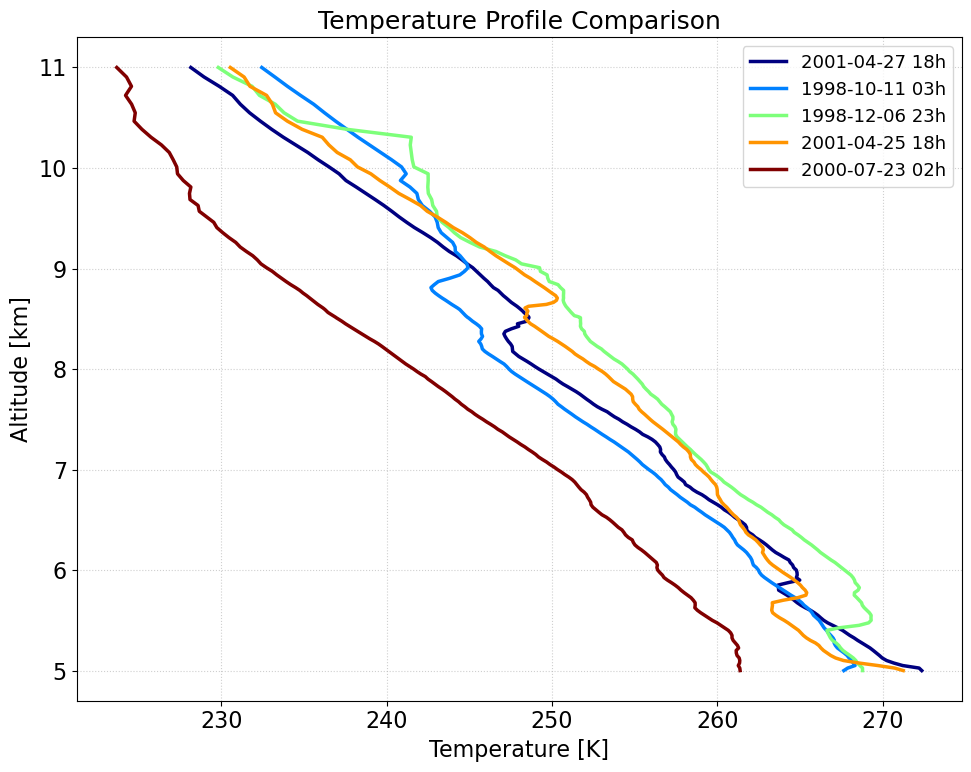

In [48]:
plt.figure(figsize=(10, 8))

for i, filename in enumerate(selected_files):
    
    # 1. Data Extraction
    prof_data = data_dict[filename]
    T = prof_data['Temperature'] # K
    P = prof_data['Pressure']    # hPa
    P_w = prof_data['P_water']   # hPa
    
    date_label = parse_date_from_filename(filename)
    
    # 2. Physics Calculations
    
    # Water Vapor Density (Ideal Gas Law)
    # rho = e / (R_v * T)
    # P_w in hPa -> *100 for Pascals. Result in kg/m3 -> *1000 for g/m3
    rho_water = (P_w * 100.0) / (R_WATER * T) * 1000.0 # g/m^3
    
    # Total PWV (for z_moy calculation)
    # Integral of rho(g/m3) dz(m) = g/m2. Divide by 1000 for kg/m2 (mm)
    pwv_total = trapezoid(rho_water, x=z_common) / 1000.0
    
    # Center of Mass (z_moy)
    # Integral (z * rho) / Integral (rho)
    if pwv_total > 0:
        z_moy = trapezoid(rho_water * z_common, x=z_common) / (pwv_total * 1000.0)
    else:
        z_moy = 0
        
    # Integrated Water Vapor vs Z (Reverse Cumulative)
    # We want Integral from z to z_max.
    # cumtrapz gives Integral from z_min to z.
    # So: Int(z->max) = Total - Int(min->z)
    cumul_from_bottom = cumulative_trapezoid(rho_water, x=z_common, initial=0) / 1000.0
    integrated_water_profile = pwv_total - cumul_from_bottom
    
    # Force the last point to be exactly 0 (numerical precision)
    integrated_water_profile[-1] = 0.0
    
    # 3. Plotting
    c = colors[i]
    plt.plot(T, z_common/1000, color=c, label=date_label)
    # We need to find the Y-value (Integrated Water) at X = z_moy
plt.xlabel(r"Temperature [K]")
plt.ylabel("Altitude [km]")
plt.title("Temperature Profile Comparison")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

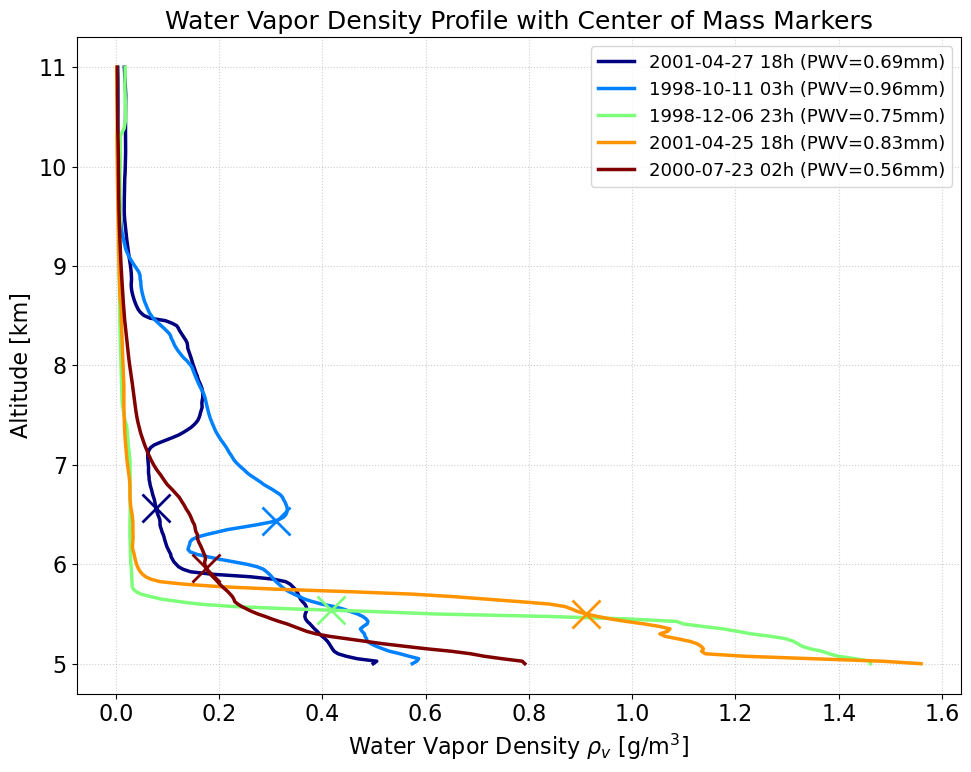

In [46]:
plt.figure(figsize=(10, 8))

for i, filename in enumerate(selected_files):
    
    # 1. Data Extraction
    prof_data = data_dict[filename]
    T = prof_data['Temperature'] # K
    P = prof_data['Pressure']    # hPa
    P_w = prof_data['P_water']   # hPa
    
    date_label = parse_date_from_filename(filename)
    
    # 2. Physics Calculations
    
    # Water Vapor Density (Ideal Gas Law)
    # rho = e / (R_v * T)
    # P_w in hPa -> *100 for Pascals. Result in kg/m3 -> *1000 for g/m3
    rho_water = (P_w * 100.0) / (R_WATER * T) * 1000.0 # g/m^3
    
    # Total PWV (for z_moy calculation)
    # Integral of rho(g/m3) dz(m) = g/m2. Divide by 1000 for kg/m2 (mm)
    pwv_total = trapezoid(rho_water, x=z_common) / 1000.0
    
    # Center of Mass (z_moy)
    # Integral (z * rho) / Integral (rho)
    if pwv_total > 0:
        z_moy = trapezoid(rho_water * z_common, x=z_common) / (pwv_total * 1000.0)
    else:
        z_moy = 0
        
    # Integrated Water Vapor vs Z (Reverse Cumulative)
    # We want Integral from z to z_max.
    # cumtrapz gives Integral from z_min to z.
    # So: Int(z->max) = Total - Int(min->z)
    cumul_from_bottom = cumulative_trapezoid(rho_water, x=z_common, initial=0) / 1000.0
    integrated_water_profile = pwv_total - cumul_from_bottom
    
    # Force the last point to be exactly 0 (numerical precision)
    integrated_water_profile[-1] = 0.0
    
    # 3. Plotting
    c = colors[i]
    plt.plot(rho_water, z_common/1000, color=c, label=date_label+f' (PWV={pwv_total:.2f}mm)')
    # We need to find the Y-value (Integrated Water) at X = z_moy
    y_at_zmoy = np.interp(z_moy/1000, z_common/1000, rho_water)
    plt.plot(y_at_zmoy, z_moy/1000, marker='x', color=c, markersize=20, markeredgewidth=2)
plt.xlabel(r"Water Vapor Density $\rho_{v}$ [g/m$^3$]")
plt.ylabel("Altitude [km]")
plt.title("Water Vapor Density Profile with Center of Mass Markers")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf
from astropy import units as u
from scipy.integrate import trapezoid
from scipy.optimize import minimize
from src.cosmo_lidar.atm_tools import atmospheric_transmission

# =============================================================================
# 2. FONCTIONS DE L'OPTIMISEUR (GÉNÉRATION PROFIL)
# =============================================================================

def generate_profile(params, z_grid, rho_base_profile, rho_lim):
    """Génère rho(z) = Base + Gaussienne, clippé par rho_lim"""
    amp = np.exp(params[0])   
    center = params[1]
    width = np.exp(params[2]) 
    
    base = rho_base_profile * 0.01 
    gaussian = amp * np.exp(-0.5 * ((z_grid - center) / width)**2)
    rho_total = base + gaussian
    
    # Respect de la contrainte physique (Saturation)
    return np.minimum(rho_total, rho_lim)

def objective_function(params, z_grid, target_pwv, target_zmoy, rho_base_profile, rho_lim):
    """Minimise l'erreur sur PWV et z_moy avec pénalité de saturation"""
    rho_trial = generate_profile(params, z_grid, rho_base_profile, rho_lim)
    
    pwv_calc = trapezoid(rho_trial, x=z_grid) / 1000.0
    if pwv_calc < 1e-6: z_moy_calc = 0
    else: z_moy_calc = trapezoid(rho_trial * z_grid, x=z_grid) / (pwv_calc * 1000.0)
    
    # Coûts quadratiques
    err_pwv = ((pwv_calc - target_pwv) / target_pwv) ** 2 * 500 # Priorité absolue PWV
    err_zmoy = ((z_moy_calc - target_zmoy) / target_zmoy) ** 2 * 10
    
    # Pénalité "Soft" si on essaie de dépasser la saturation
    amp = np.exp(params[0])
    center = params[1]
    width = np.exp(params[2])
    gaussian_pure = amp * np.exp(-0.5 * ((z_grid - center) / width)**2)
    ratio = np.max(gaussian_pure / rho_lim)
    
    penalty = (ratio - 1.0) * 100 if ratio > 1.0 else 0
        
    return err_pwv + err_zmoy + penalty

# =============================================================================
# 3. ENVIRONNEMENT ET OPTIMISATION
# =============================================================================

# Grille
altitudes = np.geomspace(1, 15000, 300) + 4999 
altitudes_km = (altitudes * u.m).to(u.km)

# Profils Standards
profile = pycraf.atm.profile_standard(altitudes_km)
T_std = profile[0].value        
P_std = profile[1].value        
P_water_base = profile[3].value 
R_water = 461.5

# Saturation (95% RH)
Tc = T_std - 273.15
P_sat = 6.112 * np.exp((17.67 * Tc) / (Tc + 243.5))
rho_sat = (P_sat * 100) / (R_water * T_std) * 1000 
rho_limit = rho_sat * 0.95

# Cibles
pwv_target = 1.0 # mm
z_targets = [5300, 6000, 6700] # m
rho_std_base = (P_water_base * 100) / (R_water * T_std) * 1000

profiles_optimized = []
print(f"Optimisation pour PWV={pwv_target}mm aux altitudes {z_targets}...")

for z_t in z_targets:
    x0 = [np.log(2.0), z_t, np.log(1000.0)]
    bounds = [(np.log(0.01), np.log(100.0)), (5000.0, 12000.0), (np.log(50.0), np.log(10000.0))]
    
    res = minimize(objective_function, x0, args=(altitudes, pwv_target, z_t, rho_std_base, rho_limit),
                   bounds=bounds, method='L-BFGS-B')
    
    final_rho = generate_profile(res.x, altitudes, rho_std_base, rho_limit)
    
    # Validation stats finales
    final_pwv = trapezoid(final_rho, x=altitudes) / 1000.0
    final_zmoy = trapezoid(final_rho * altitudes, x=altitudes) / (final_pwv * 1000.0)
    final_P_water = (final_rho * R_water * T_std) / 100.0 / 1000.0
    
    profiles_optimized.append({
        "z_target": z_t, "z_moy": final_zmoy, "PWV": final_pwv,
        "rho": final_rho, "P_water": final_P_water
    })
    print(f" -> Cible {z_t}m : z_moy={final_zmoy:.0f}m, PWV={final_pwv:.4f}mm")

# =============================================================================
# 4. CALCUL SPECTRAL ET VISUALISATION
# =============================================================================

# Gamme de fréquences
frequencies_spec = np.linspace(30e9, 300e9, 1000)
freq_ghz = frequencies_spec / 1e9
elevation = 45

print("Calcul des spectres de transmission...")
spectra = []
for prof in profiles_optimized:
    trans = atmospheric_transmission(frequencies_spec, altitudes, T_std, P_std, prof["P_water"], elevation)
    spectra.append(trans)



Optimisation pour PWV=1.0mm aux altitudes [5300, 6000, 6700]...
 -> Cible 5300m : z_moy=5578m, PWV=0.9999mm
 -> Cible 6000m : z_moy=6139m, PWV=1.0000mm
 -> Cible 6700m : z_moy=6798m, PWV=1.0000mm
Calcul des spectres de transmission...


[]

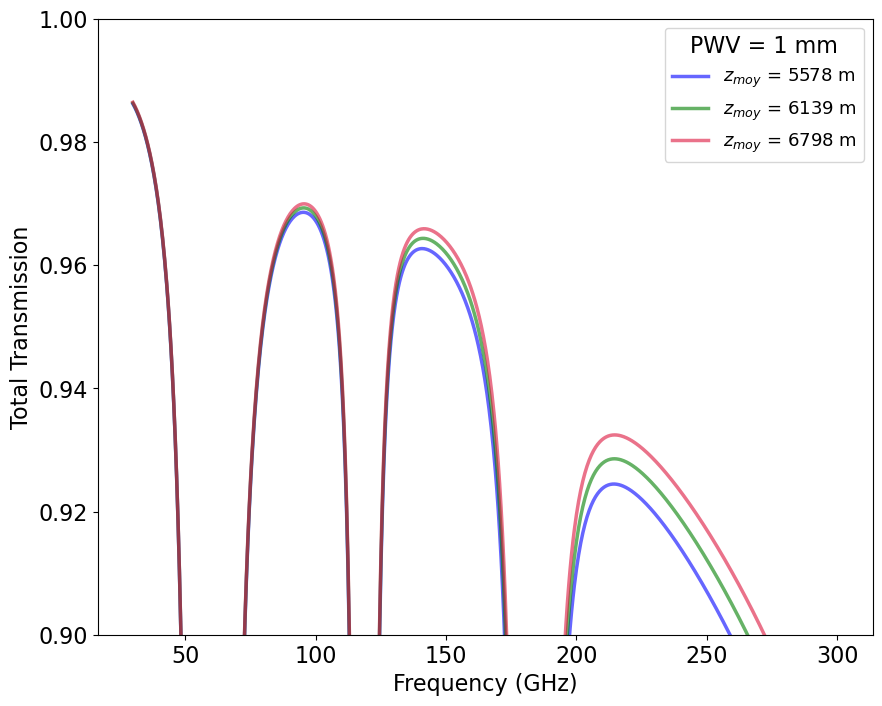

In [ ]:
colors = ['blue', 'green', 'crimson']
plt.figure(figsize=(10,8))

for i, trans in enumerate(spectra):
    lbl = f"$z_{{moy}}$ = {profiles_optimized[i]['z_moy']:.0f} m"
    plt.plot(freq_ghz, trans, color=colors[i], label=lbl, alpha=0.6)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Total Atmospheric Transmission")
plt.legend(title='PWV = 1 mm')
plt.ylim(0.90, 1)
plt.plot()


In [29]:
from src.cosmo_lidar.atm_tools import Calcul_T_sky_1_el
# --- Lancement du calcul sur le spectre (30-300 GHz) ---
print("\nCalcul des spectres T_sky en cours...")

sky_spectra = []

for prof in profiles_optimized:
    # On utilise les profils P_water optimisés
    tsky = Calcul_T_sky_1_el(
        frequencies_spec, 
        altitudes, 
        T_std, 
        P_std, 
        prof["P_water"], 
        elevation
    )
    sky_spectra.append(tsky)


Calcul des spectres T_sky en cours...


[]

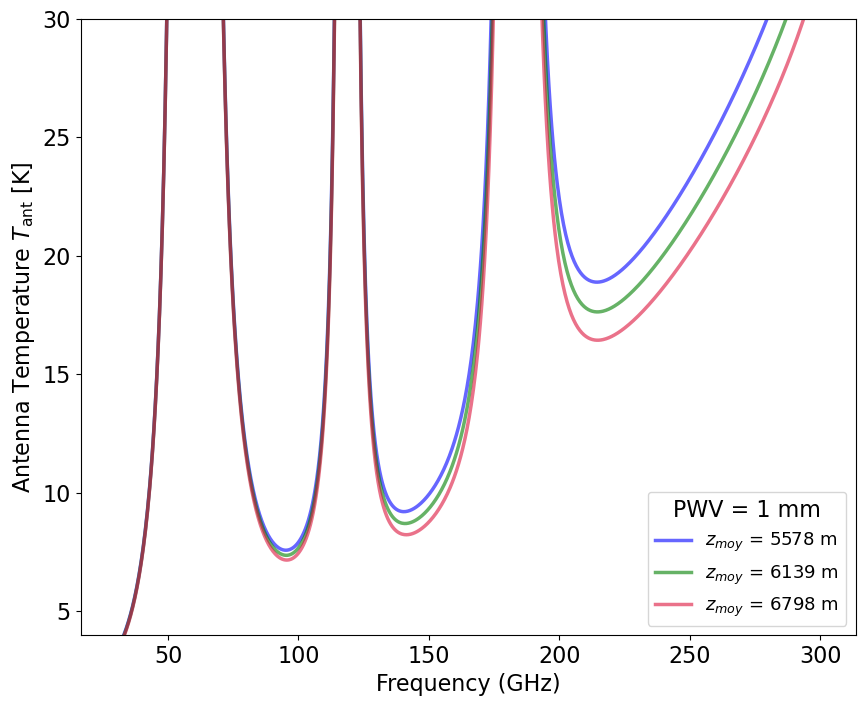

In [32]:
plt.figure(figsize=(10,8))
for i, trans in enumerate(spectra):
    lbl = f"$z_{{moy}}$ = {profiles_optimized[i]['z_moy']:.0f} m"
    plt.plot(freq_ghz, sky_spectra[i], color=colors[i], label=lbl, alpha=0.6)
plt.xlabel("Frequency (GHz)")
plt.ylabel(r"Antenna Temperature $T_{\mathrm{ant}}$ [K]")
plt.legend(title='PWV = 1 mm')
plt.ylim(4,30)
plt.plot()